In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   


In [2]:
df = pd.read_csv(r"C:\Users\Sonal Thorat\Downloads\bank-additional-full-1.csv", sep=';')
# sep=';' is used to specify that the values in the CSV file are separated by semicolons instead of commas.
# This is necessary because the default separator for CSV files is a comma, and if the values

In [3]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Now we are gonna use the loigstic regression.
# 

In [5]:
df.isnull().sum()

age               4
job               5
marital           5
education         5
default           4
housing           3
loan              4
contact           4
month             3
day_of_week       3
duration          3
campaign          3
pdays             3
previous          3
poutcome          5
emp.var.rate      3
cons.price.idx    4
cons.conf.idx     3
euribor3m         3
nr.employed       3
y                 3
dtype: int64

In [6]:
df.dropna(inplace= True)

In [7]:
df.shape 

(41190, 21)

In [8]:
df['y'].mode()[0]

'no'

In [9]:
df['age'].mean()

np.float64(40.02619567856276)

In [10]:
df.duplicated().sum()

np.int64(13)

In [11]:
df.drop_duplicates(inplace= True)

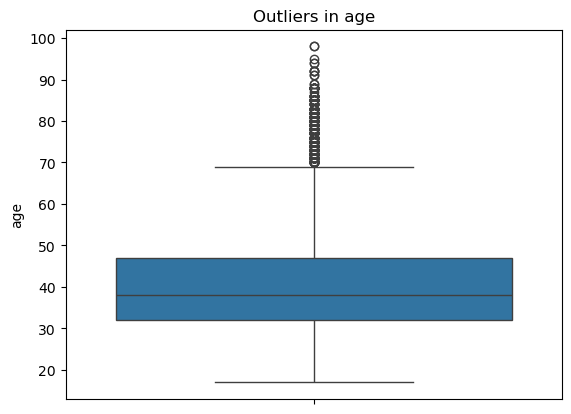

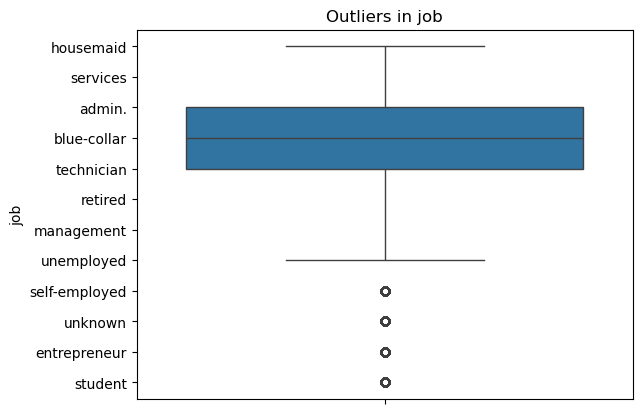

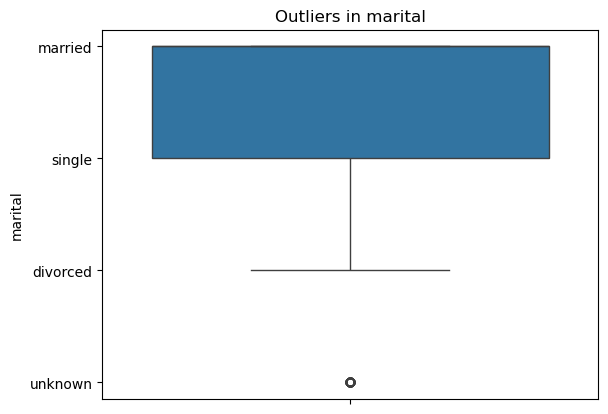

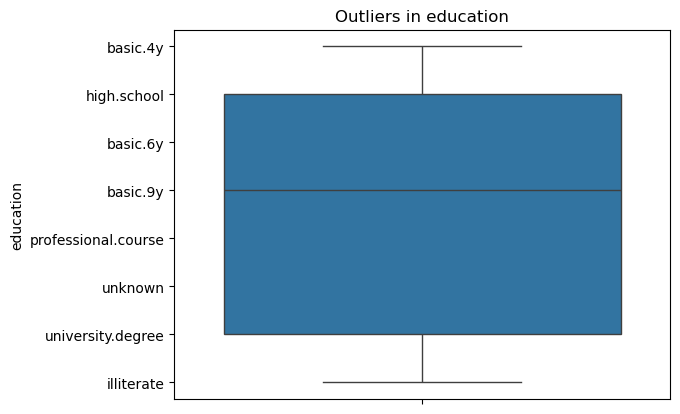

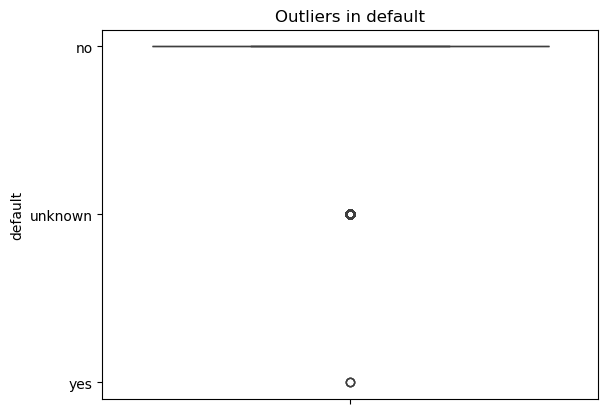

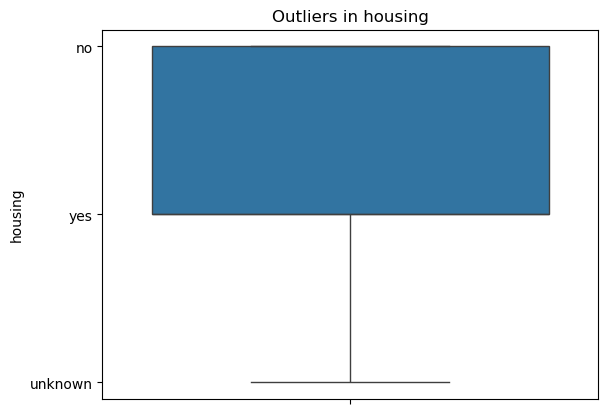

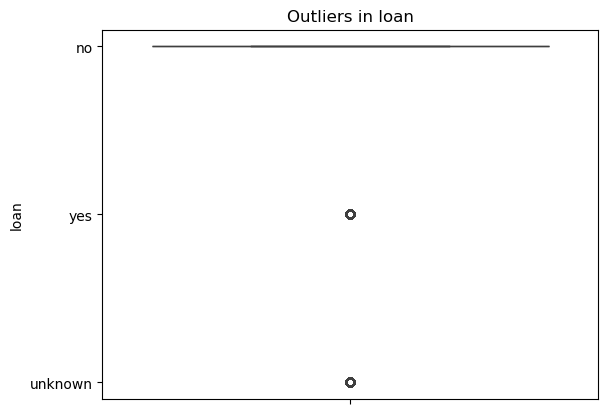

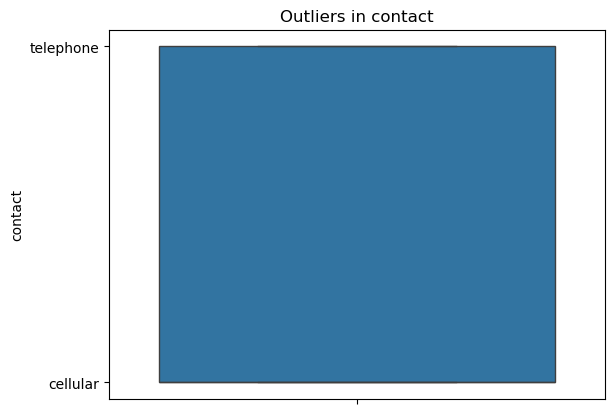

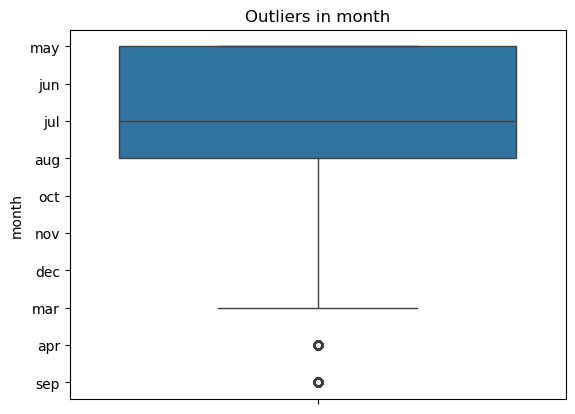

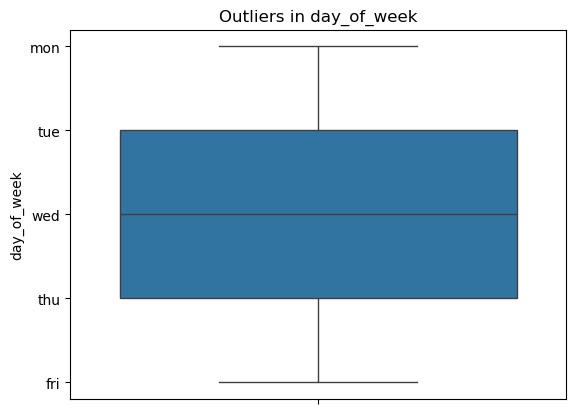

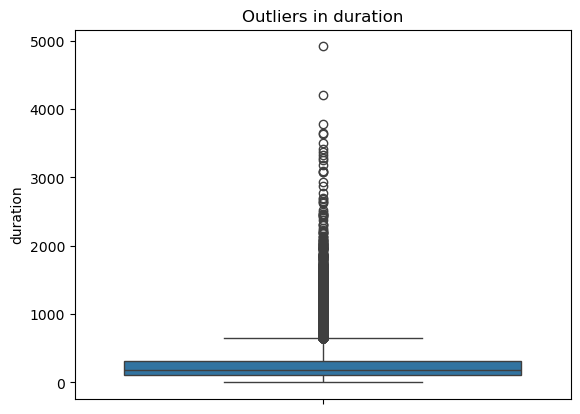

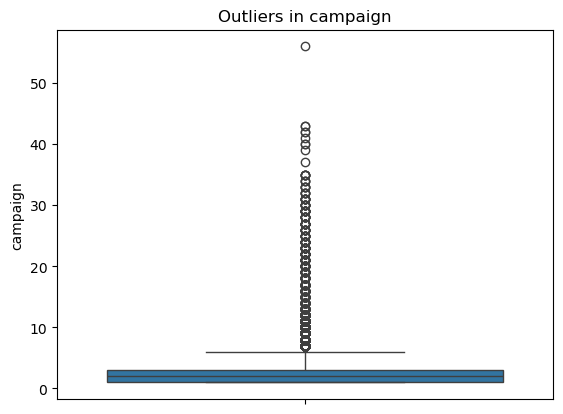

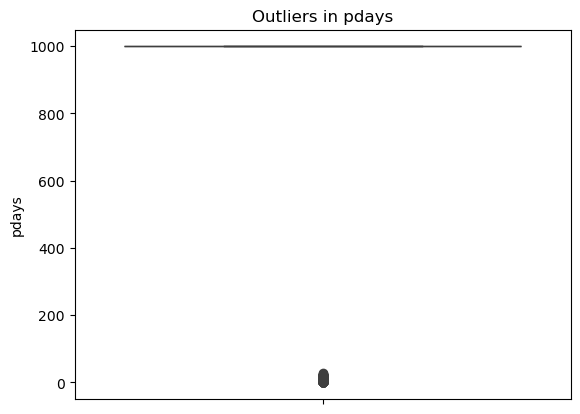

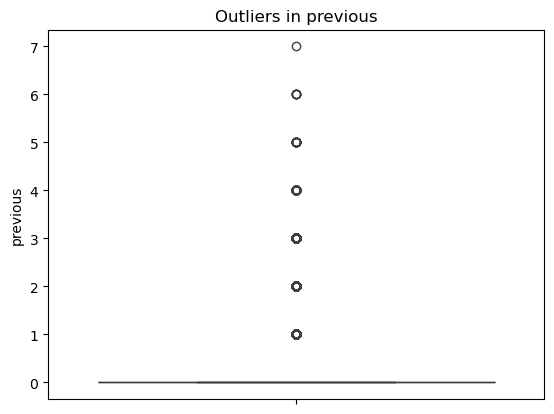

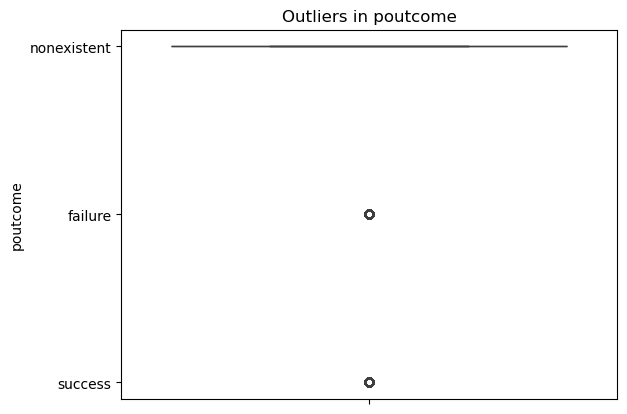

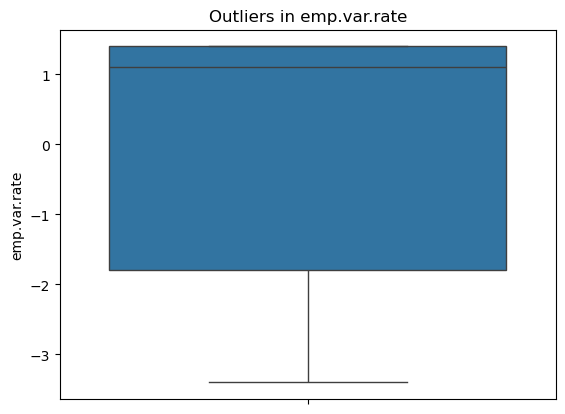

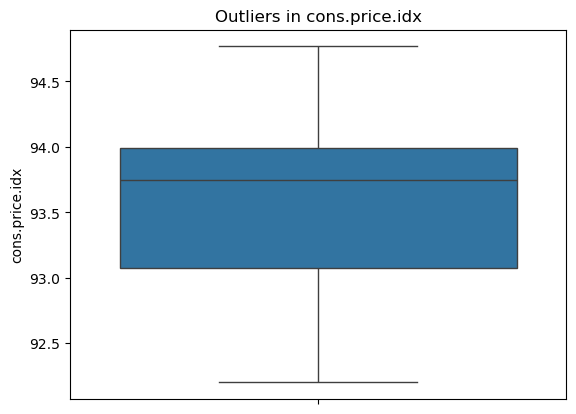

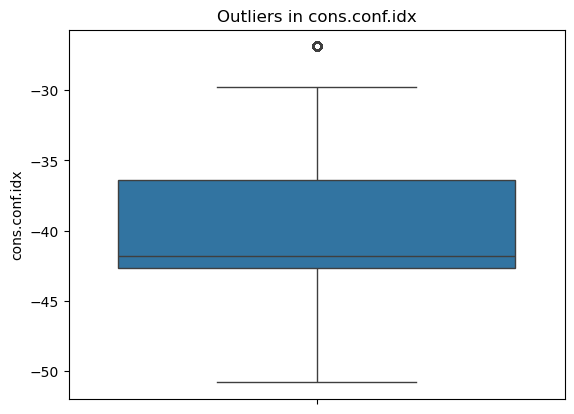

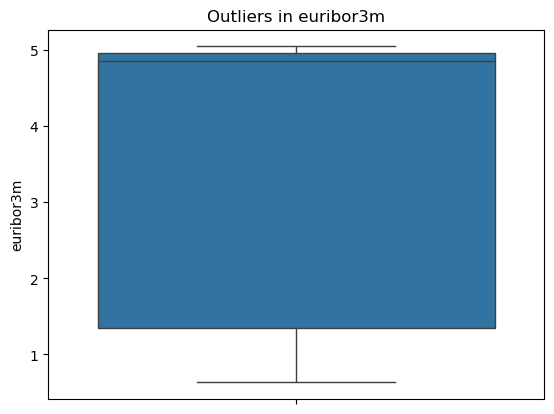

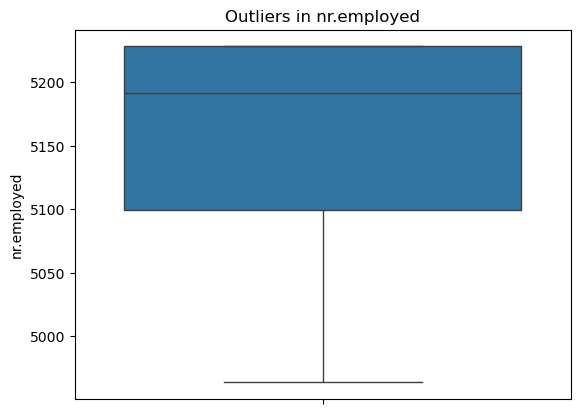

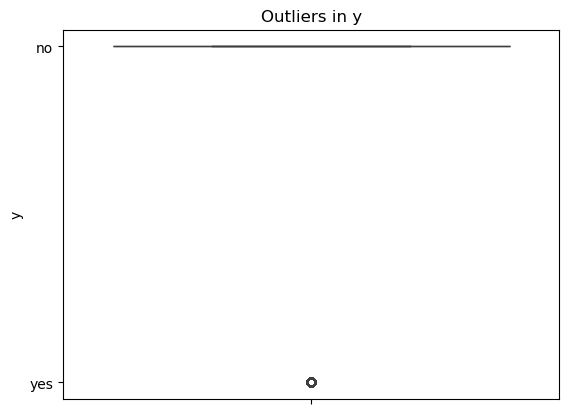

In [12]:
# Now we are gonna detect ehe outliers in the all the columns  using the boxplot and then we will remove them and after creating we are gonna name the each graphs.
for i in df.columns:
    sns.boxplot(df[i])
    plt.title(f'Outliers in {i}')
    plt.show()


In [13]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41184,46.0,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56.0,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44.0,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [14]:
# Handling the outliers using the IQR method
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower) | (df['age'] > upper)]
print(len(outliers))

469


In [15]:
Q1 = df['campaign'].quantile(0.25)
Q3 = df['campaign'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['campaign'] < lower) | (df['campaign'] > upper)]
print(len(outliers))

2406


In [16]:
# Handling the outliers using the IQR method.

Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['duration'] < lower) | (df['duration'] > upper)]
print(len(outliers))

2963


In [17]:
Q1 = df['cons.conf.idx'].quantile(0.25)
Q3 = df['cons.conf.idx'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['cons.conf.idx'] < lower) | (df['cons.conf.idx'] > upper)]
print(len(outliers))

446


In [18]:
# Enocding : converting the objects columns into the numerical.
# we have to do label encoding 
from sklearn.preprocessing import LabelEncoder

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41177 entries, 0 to 41193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41177 non-null  float64
 1   job             41177 non-null  object 
 2   marital         41177 non-null  object 
 3   education       41177 non-null  object 
 4   default         41177 non-null  object 
 5   housing         41177 non-null  object 
 6   loan            41177 non-null  object 
 7   contact         41177 non-null  object 
 8   month           41177 non-null  object 
 9   day_of_week     41177 non-null  object 
 10  duration        41177 non-null  float64
 11  campaign        41177 non-null  float64
 12  pdays           41177 non-null  float64
 13  previous        41177 non-null  float64
 14  poutcome        41177 non-null  object 
 15  emp.var.rate    41177 non-null  float64
 16  cons.price.idx  41177 non-null  float64
 17  cons.conf.idx   41177 non-null  floa

In [20]:
# We have to convert the objects columns into the numerical columns using the label encoding.
le = LabelEncoder()
for i in df.columns:
    if df[i].dtype == 'object':
        df[i] = le.fit_transform(df[i]) # only fit : is to learn & transform : is to convert the values 
        

In [21]:
df # after encoding the objects columns into the numerical columns.

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,3,1,0,0,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57.0,7,1,3,1,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37.0,7,1,3,0,2,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40.0,0,1,1,0,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56.0,7,1,3,0,0,2,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41184,46.0,1,1,5,0,0,0,0,7,0,...,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56.0,5,1,6,0,2,0,0,7,0,...,2.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44.0,9,1,5,0,0,0,0,7,0,...,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41187,74.0,5,1,5,0,2,0,0,7,0,...,3.0,999.0,1.0,0,-1.1,94.767,-50.8,1.028,4963.6,0


In [22]:
# Model Building
'''
1. import the lib 
2. split our data into (independent(x) and dependent(y))
3.Train test split
4.Train the model
5.Evaluate the model
'''

'\n1. import the lib \n2. split our data into (independent(x) and dependent(y))\n3.Train test split\n4.Train the model\n5.Evaluate the model\n'

In [23]:
# 1.importing the libraries for model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [24]:
# 2. split our data into (independent(x) and dependent(y))
x = df.drop(columns = "y")


In [25]:
x

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56.0,3,1,0,0,0,0,1,6,1,261.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
1,57.0,7,1,3,1,0,0,1,6,1,149.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
2,37.0,7,1,3,0,2,0,1,6,1,226.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
3,40.0,0,1,1,0,0,0,1,6,1,151.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
4,56.0,7,1,3,0,0,2,1,6,1,307.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41184,46.0,1,1,5,0,0,0,0,7,0,383.0,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6
41185,56.0,5,1,6,0,2,0,0,7,0,189.0,2.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6
41186,44.0,9,1,5,0,0,0,0,7,0,442.0,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6
41187,74.0,5,1,5,0,2,0,0,7,0,239.0,3.0,999.0,1.0,0,-1.1,94.767,-50.8,1.028,4963.6


In [26]:
y = df['y']

In [27]:
y.shape

(41177,)

In [28]:
x.shape

(41177, 20)

In [29]:
df.shape

(41177, 21)

In [30]:
# Train test split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [31]:
x_train

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
12348,29.0,2,1,1,0,2,2,1,3,0,286.0,3.0,999.0,0.0,1,1.4,93.918,-42.7,4.959,5228.1
8565,50.0,0,2,6,0,0,0,1,4,4,178.0,6.0,999.0,0.0,1,1.4,94.465,-41.8,4.864,5228.1
21424,29.0,0,2,6,0,0,0,0,1,3,103.0,4.0,999.0,0.0,1,1.4,93.444,-36.1,4.963,5228.1
3316,35.0,0,2,6,0,0,0,1,6,2,135.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.860,5191.0
33246,40.0,1,2,3,1,0,0,0,6,3,418.0,1.0,999.0,0.0,1,-1.8,92.893,-46.2,1.291,5099.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6266,34.0,1,1,2,0,0,2,1,6,3,100.0,2.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
11285,29.0,0,1,2,0,2,0,1,4,2,120.0,1.0,999.0,0.0,1,1.4,94.465,-41.8,4.961,5228.1
38169,71.0,5,1,0,0,0,0,0,8,2,250.0,2.0,999.0,2.0,0,-3.4,92.431,-26.9,0.754,5017.5
860,40.0,4,1,6,0,2,0,1,6,4,295.0,2.0,999.0,0.0,1,1.1,93.994,-36.4,4.856,5191.0


In [32]:
x_test

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
36265,32.0,9,2,6,0,0,0,0,4,1,1048.0,1.0,999.0,0.0,1,-2.9,92.963,-40.8,1.266,5076.2
32672,34.0,1,1,2,0,0,0,0,6,1,248.0,1.0,999.0,1.0,0,-1.8,92.893,-46.2,1.299,5099.1
40873,32.0,0,1,3,0,2,0,1,8,4,48.0,1.0,999.0,0.0,1,-1.1,94.601,-49.5,0.959,4963.6
32907,53.0,0,1,3,0,2,2,0,6,1,186.0,2.0,999.0,1.0,0,-1.8,92.893,-46.2,1.299,5099.1
16464,24.0,7,2,2,0,2,0,1,3,4,184.0,1.0,999.0,0.0,1,1.4,93.918,-42.7,4.963,5228.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19004,53.0,1,1,0,0,0,0,0,1,3,76.0,1.0,999.0,0.0,1,1.4,93.444,-36.1,4.968,5228.1
34252,30.0,9,1,2,0,2,0,1,6,2,7.0,7.0,999.0,0.0,1,-1.8,92.893,-46.2,1.266,5099.1
13575,54.0,10,1,6,1,0,0,1,3,2,106.0,1.0,999.0,0.0,1,1.4,93.918,-42.7,4.963,5228.1
1872,46.0,1,1,5,0,2,0,1,6,0,106.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.855,5191.0


In [33]:
y_train

12348    0
8565     0
21424    0
3316     0
33246    0
        ..
6266     0
11285    0
38169    0
860      0
15798    0
Name: y, Length: 32941, dtype: int64

In [34]:
y_test

36265    1
32672    0
40873    0
32907    0
16464    0
        ..
19004    0
34252    0
13575    0
1872     0
12339    0
Name: y, Length: 8236, dtype: int64

In [35]:
model = LogisticRegression()

In [36]:
model.fit(x_train, y_train)

c:\Users\Sonal Thorat\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
predict = model.predict(x_test)

In [38]:
predict

array([1, 0, 0, ..., 0, 0, 0], shape=(8236,))

In [39]:
result = pd.DataFrame(columns=['Actual Values', 'Predicted Values'])
result['Actual Values'] = y_test
result['Predicted Values'] = predict

In [40]:
result

,Actual Values,Predicted Values
36265,1,1
32672,0,0
40873,0,0
32907,0,0
16464,0,0
...,...,...
19004,0,0
34252,0,0
13575,0,0
1872,0,0


In [41]:
# Evaluation of the model
from sklearn.metrics import *

In [42]:
accuracy_score = accuracy_score(y_test, predict) 
#  It measures how often the model’s predictions are correct out of all predictions made.

In [43]:
accuracy_score

0.9020155415250122

In [44]:
confusion_matrix(y_test, predict)

array([[7056,  196],
       [ 611,  373]])

In [45]:
'''
     ([[7056,  196],
       [ 611,  373]])

       [[TN , FP]]
        [FN , TP]]

1. 7056 : True Negatives (TN) - The model correctly predicted the negative class (0) 7056 times.
2. 196 : False Positives (FP) - The model incorrectly predicted the positive class (1) 196 times.
3. 611 : False Negatives (FN) - The model incorrectly predicted the negative class (0) when it was actually positive (1) 611 times.
4. 373 : True Positives (TP) - The model correctly predicted the positive class (1) 373 times.

'''

'\n     ([[7056,  196],\n       [ 611,  373]])\n\n       [[TN , FP]]\n        [FN , TP]]\n\n1. 7056 : True Negatives (TN) - The model correctly predicted the negative class (0) 7056 times.\n2. 196 : False Positives (FP) - The model incorrectly predicted the positive class (1) 196 times.\n3. 611 : False Negatives (FN) - The model incorrectly predicted the negative class (0) when it was actually positive (1) 611 times.\n4. 373 : True Positives (TP) - The model correctly predicted the positive class (1) 373 times.\n\n'

In [46]:
# TN(True Negative) -> When the Actual value is Negative(0) and your model is also predicting it as Negative(0)
# FP(False Positive) -> When the Actual value is Negative(0) but your model is predicting it as Positive(1)
# FN(False Negative) -> When the Actual value is Positive(1) but your model is predicting it as Negative(0)
# TP(True Positive) -> When the Actual value is Positive(1) and your model is also predicting it as Positive(1)

In [47]:
# Accuracy -> (How many times model is correct) / (All the prediction model have made)

In [48]:
Accruracy = (7056 + 373) / (7056 + 196 + 611 + 373) # --> This is how we can calculate the accuracy score.
Accruracy

0.9020155415250122

In [49]:
df["y"].value_counts() # --> Answer column .
'''
y
0    36538 --> no 
1     4639 --> yes

'''

'\ny\n0    36538 --> no \n1     4639 --> yes\n\n'

In [50]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,3,1,0,0,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57.0,7,1,3,1,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37.0,7,1,3,0,2,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40.0,0,1,1,0,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56.0,7,1,3,0,0,2,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [51]:
print (classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7252
           1       0.66      0.38      0.48       984

    accuracy                           0.90      8236
   macro avg       0.79      0.68      0.71      8236
weighted avg       0.89      0.90      0.89      8236



In [52]:
print (confusion_matrix(y_test , predict))

[[7056  196]
 [ 611  373]]


In [53]:
# Precision : How many times your model is correct (class -> pos/neg) among all the times it says correct.


In [54]:
# 0 -> Negative
# How many time your model prediction is negative from that how many times the actual is also negative

In [55]:
# TN
# TN, FN
# precision => TN/(TN+FN)

In [56]:
7056/(7056+611) # --> 0.9203

0.9203078127037955

In [57]:
# 1 --> Positive
# TP / ( TP + FP)
373 / ( 373 + 196)

0.655536028119508

In [58]:
# Recall -> How many times your model is correct among how many times the atual value is correct(class pos/neg)

In [59]:
# 0 -> Negative
# How many times your model is prediction negative class correctly among how many time the actual value is negative

In [60]:
print (confusion_matrix(y_test , predict))

[[7056  196]
 [ 611  373]]


In [61]:
# TN / (TN+FP)
7056 / ( 7056 + 196)


0.972972972972973

In [62]:
# 1--> positive 
# TP / (TP+FN)

In [63]:
373 / ( 373 + 611)

0.3790650406504065

In [64]:
# F1_score -->  The balance between Precision and Recall , Harmonic mean of precision and recall/
# 2 * [(Precision * Recall)/(Precision+Recall)]

In [65]:
# 0 --> Negative 
2*((0.9203078127037955*0.972972972972973 )/(0.9203078127037955 +0.972972972972973 ))

0.945907902674442

In [66]:
# 1 --> Positive 
2*((0.655536028119508 * 0.3790650406504065) / (0.655536028119508 +.3790650406504065 ))

0.48036059240180295

In [67]:
print (classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7252
           1       0.66      0.38      0.48       984

    accuracy                           0.90      8236
   macro avg       0.79      0.68      0.71      8236
weighted avg       0.89      0.90      0.89      8236

